# Step 2 - Train Neural Network crop classifier


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path


REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent


DATA_PREP = REPO_ROOT / "data" / "prepared"
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)


# Filenames (edit ONLY these if your filenames differ)
data_file = DATA_PREP / "S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv"
classes_file = DATA_PREP / "LUCAS_2018_Copernicus_attributes_cropmap_level1-2_FROM_EXPORTS.csv"


# Friendly errors if files are missing
assert data_file.exists(), f"Missing dataset file: {data_file}"
assert classes_file.exists(), f"Missing classes file: {classes_file}"


print("Using data_file:", data_file)
print("Using classes_file:", classes_file)
print("Saving outputs to:", MODELS_DIR)


Using data_file: /workspace/eucropmap-reprod-kz/data/prepared/S1_point_all_10d_10m_20180101-20180731_Stratum1_VV-VH.csv
Using classes_file: /workspace/eucropmap-reprod-kz/data/prepared/LUCAS_2018_Copernicus_attributes_cropmap_level1-2_FROM_EXPORTS.csv
Saving outputs to: /workspace/eucropmap-reprod-kz/models


In [2]:
class_table = pd.read_csv(classes_file)
print(class_table)


       POINT_ID  stratum  LC1   LU1  level_1  level_2
0      47242864        1  B11  U111      200      211
1      47322804        1  B11  U111      200      211
2      47602810        1  B11  U111      200      211
3      47622814        1  B11  U111      200      211
4      47642818        1  B11  U111      200      211
...         ...      ...  ...   ...      ...      ...
30929  36503184        1  E20  U111      500      500
30930  36643156        1  E20  U111      500      500
30931  36703150        1  E20  U111      500      500
30932  36503170        1  F40  U111      200      290
30933  36883144        1  F40  U112      200      290

[30934 rows x 6 columns]


In [3]:
# Load class legend table 

classes_L1 = class_table["level_1"].dropna().unique().tolist()
classes_L2 = class_table["level_2"].dropna().unique().tolist()

df = pd.read_csv(data_file, dtype={'level_1': int, 'level_2': int})
print(f"Loaded dataset with shape {df.shape}")


Loaded dataset with shape (1743815, 46)


In [4]:
#official Level-2 set:
L2_official = {211,212,213,214,215,216,217,218,219,221,222,223,230,231,232,233,240,250,290}



# sremove non crop labled data
bad_L1 = {100,300,500,600}
classes_L2 = [c for c in classes_L2 if c in L2_official]

print(f"Classes in level_1: {classes_L1}")
print(f"Classes in level_2: {classes_L2}")
print(df.head())

Classes in level_1: [200, 500, 300, 600, 100]
Classes in level_2: [211, 212, 213, 214, 215, 216, 218, 219, 221, 222, 223, 231, 232, 233, 230, 240, 250, 290]
   POINT_ID  stratum  level_1  level_2  VH_20180101  VH_20180111  VH_20180121  \
0  47242864        1      200      211   -17.729420   -20.325294   -19.684908   
1  47242864        1      200      211   -17.629759   -20.395664   -19.362911   
2  47322804        1      200      211   -16.761300   -16.439291   -19.003990   
3  47322804        1      200      211   -16.949911   -17.447950   -18.359556   
4  47322804        1      200      211   -16.443756   -16.525919   -18.132175   

   VH_20180131  VH_20180210  VH_20180220  ...  VV_20180421  VV_20180501  \
0   -20.850082   -20.764990   -23.271540  ...   -15.297538   -14.691077   
1   -20.440153   -21.169271   -23.260570  ...   -13.002155   -14.203595   
2   -20.409580   -22.091795   -21.210240  ...   -16.568722   -17.411484   
3   -20.564657   -23.349674   -21.620611  ...   -16.0513

In [5]:
df['Classif'] = df['level_2']  # working label for classification (detailed crop types)
if classes_L2:
    df = df[df['Classif'].isin(classes_L2)]
print(f"Data after filtering to crop classes: {df.shape}")



Data after filtering to crop classes: (604610, 47)


In [6]:

feature_regex = r'(((?<![\w\d])VH_)|((?<![\w\d])VV_))'  
feature_regex += r'(2018(0[1-7]))'  

X = df.filter(regex=feature_regex)
y = df['Classif']

print(f"Selected features matrix X shape: {X.shape}")
print(f"Selected target vector y shape: {y.shape}")
# Check a quick summary of class distribution
print("Class distribution in y:")
print(y.value_counts())
#  feature names used in training
import json, os

feature_names = list(X.columns)
feat_path = MODELS_DIR / "RF_feature_names.json"
with open(feat_path, "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"Saved training feature list to {feat_path}")


Selected features matrix X shape: (604610, 42)
Selected target vector y shape: (604610,)
Class distribution in y:
Classif
211    195821
213     89215
216     69089
232     53663
214     31153
290     24290
215     24001
250     23366
222     22901
240     18351
218     16124
221     14620
230      6360
212      4711
223      3780
219      3446
231      1975
233      1744
Name: count, dtype: int64
Saved training feature list to /workspace/eucropmap-reprod-kz/models/RF_feature_names.json


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)

classes = np.sort(y_train.unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_train_idx = y_train.map(class_to_idx).to_numpy(dtype=np.int64)
y_val_idx = y_val.map(class_to_idx).to_numpy(dtype=np.int64)

X_train_tensor = torch.from_numpy(X_train_scaled)
y_train_tensor = torch.from_numpy(y_train_idx)
X_val_tensor = torch.from_numpy(X_val_scaled)
y_val_tensor = torch.from_numpy(y_val_idx)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=0, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training device: {device}")
if device.type != 'cuda':
    print('WARNING: CUDA not available. Training will run on CPU.')

input_dim = X_train_tensor.shape[1]
num_classes = len(classes)

model = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, num_classes),
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
#optimizer = torch.optim.Adam(model.parameters())    

epochs = 150
train_losses = []
val_accuracies = []

print('Starting PyTorch neural network training...')
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch:02d}/{epochs} - train_loss: {epoch_loss:.4f} - val_acc: {val_acc:.4f}")

print('PyTorch neural network training completed.')


/tmp/ipykernel_3529/2266803764.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_tensor = torch.from_numpy(y_train_idx)


Training device: cuda
Starting PyTorch neural network training...
Epoch 01/150 - train_loss: 1.3805 - val_acc: 0.6673
Epoch 02/150 - train_loss: 1.1123 - val_acc: 0.6975
Epoch 03/150 - train_loss: 1.0398 - val_acc: 0.7179
Epoch 04/150 - train_loss: 0.9923 - val_acc: 0.7298
Epoch 05/150 - train_loss: 0.9543 - val_acc: 0.7418
Epoch 06/150 - train_loss: 0.9275 - val_acc: 0.7501
Epoch 07/150 - train_loss: 0.9052 - val_acc: 0.7557
Epoch 08/150 - train_loss: 0.8874 - val_acc: 0.7618
Epoch 09/150 - train_loss: 0.8738 - val_acc: 0.7678
Epoch 10/150 - train_loss: 0.8603 - val_acc: 0.7723
Epoch 11/150 - train_loss: 0.8501 - val_acc: 0.7757
Epoch 12/150 - train_loss: 0.8408 - val_acc: 0.7800
Epoch 13/150 - train_loss: 0.8349 - val_acc: 0.7814
Epoch 14/150 - train_loss: 0.8256 - val_acc: 0.7834
Epoch 15/150 - train_loss: 0.8195 - val_acc: 0.7850
Epoch 16/150 - train_loss: 0.8159 - val_acc: 0.7883
Epoch 17/150 - train_loss: 0.8094 - val_acc: 0.7896
Epoch 18/150 - train_loss: 0.8055 - val_acc: 0.791

In [8]:
# Save trained PyTorch model + preprocessing artifacts
model_path = MODELS_DIR / "MLP_torch_model.pt"

torch.save({
    'state_dict': model.state_dict(),
    'input_dim': input_dim,
    'num_classes': num_classes,
    'classes': classes,
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class,
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
}, model_path)

print(f"Saved PyTorch neural network checkpoint to {model_path}")


Saved PyTorch neural network checkpoint to /workspace/eucropmap-reprod-kz/models/MLP_torch_model.pt


In [9]:
model.eval()
val_pred_idx = []

with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(device, non_blocking=True)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        val_pred_idx.extend(preds.tolist())

y_pred = np.array([idx_to_class[i] for i in val_pred_idx])

print("Accuracy on validation set: {:.2f}%".format(100 * (y_pred == y_val.to_numpy()).mean()))
print("Confusion Matrix:\\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\\n", classification_report(y_val, y_pred))


Accuracy on validation set: 82.69%
Confusion Matrix:\n [[44522    17  1798   519   371   699   202    24    18    29     9    10
      4   238     2   131   228   134]
 [  413   639    39    29    12    25     8     1     2     0     0     0
      0     0     0     7     0     3]
 [ 2907     8 17685   330   369   483    97    18     8     5     3     4
      1    91     1    47   174    73]
 [ 1071     4   329  5391   185   293   314     2     9     3     1     0
      1    64     0    37    77     7]
 [  957     3   431   249  3969   144    72    11     4     3     1     1
      0    19     0    29    89    18]
 [  717     3   226   210    84 15492    38    11    55    68     8     4
      6   114     8   111    97    20]
 [  943     2   209   481    95   170  2061     1     4     1     0     2
      0    13     0    15    30     4]
 [   77     0     9    20    28    95     6   578     2     2     0     1
      0    15     0    18     9     1]
 [   19     0    13    10    13   188    

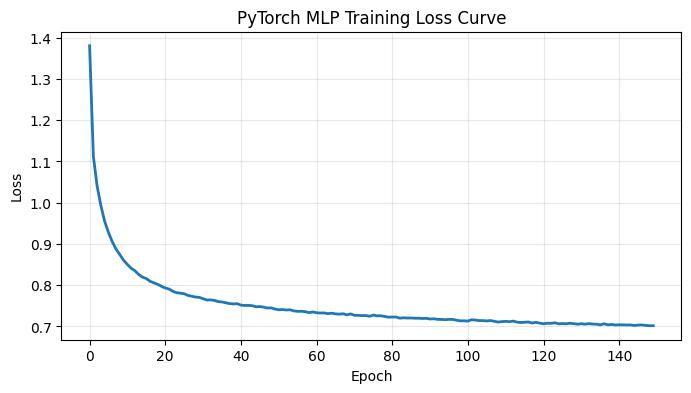

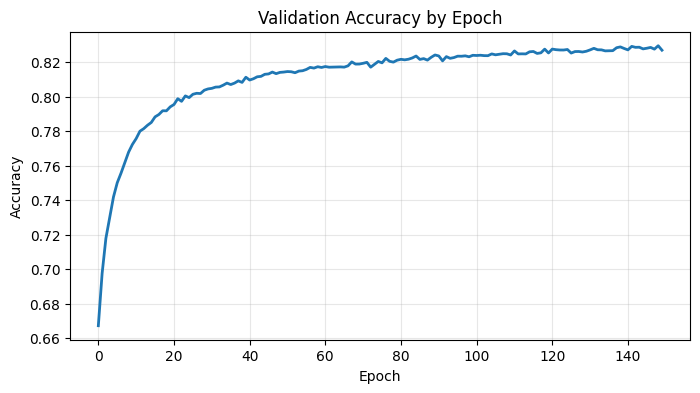

Best validation accuracy: 0.8295


In [10]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, linewidth=2)
plt.title('PyTorch MLP Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(val_accuracies, linewidth=2)
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best validation accuracy: {max(val_accuracies):.4f}")
